In [1]:
import pandas as pd

# Business Problem

A company launched a new checkout page to improve purchases.

Users are randomly assigned:

Control  >> Old checkout page

Treatment >> New checkout page

Goal: Determine if the new checkout page improves conversion rate and revenue.

## Key business metrics:

Conversion Rate comparision

Revenue impact Analysis

Average Order Value

Statistical hypothesis testing

confidence interval estimation

User Engagement

In [3]:
df = pd.read_csv('ab_testing_dataset.csv')
df

,user_id,experiment_group,session_date,clicks,time_spent,add_to_cart,purchase,order_value
0,1,control,2025-01-01 00:00:00,4,105.123608,0,0,0.000000
1,2,treatment,2025-01-01 01:00:00,3,130.788718,1,0,0.000000
2,3,control,2025-01-01 02:00:00,3,141.497317,0,0,0.000000
3,4,control,2025-01-01 03:00:00,2,86.809702,1,0,0.000000
4,5,control,2025-01-01 04:00:00,0,138.101665,0,0,0.000000
...,...,...,...,...,...,...,...,...
9995,9996,treatment,2026-02-21 11:00:00,1,111.592550,1,1,87.803582
9996,9997,control,2026-02-21 12:00:00,2,163.999012,0,0,0.000000
9997,9998,treatment,2026-02-21 13:00:00,5,131.627502,1,0,0.000000
9998,9999,treatment,2026-02-21 14:00:00,1,139.845709,1,0,0.000000


In [4]:
df.head()

,user_id,experiment_group,session_date,clicks,time_spent,add_to_cart,purchase,order_value
0,1,control,2025-01-01 00:00:00,4,105.123608,0,0,0.0
1,2,treatment,2025-01-01 01:00:00,3,130.788718,1,0,0.0
2,3,control,2025-01-01 02:00:00,3,141.497317,0,0,0.0
3,4,control,2025-01-01 03:00:00,2,86.809702,1,0,0.0
4,5,control,2025-01-01 04:00:00,0,138.101665,0,0,0.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           10000 non-null  int64  
 1   experiment_group  10000 non-null  object 
 2   session_date      10000 non-null  object 
 3   clicks            10000 non-null  int64  
 4   time_spent        10000 non-null  float64
 5   add_to_cart       10000 non-null  int64  
 6   purchase          10000 non-null  int64  
 7   order_value       10000 non-null  float64
dtypes: float64(2), int64(4), object(2)
memory usage: 625.1+ KB


In [6]:
df.isnull().sum()

user_id             0
experiment_group    0
session_date        0
clicks              0
time_spent          0
add_to_cart         0
purchase            0
order_value         0
dtype: int64

## Conversion Rate

In [ ]:
# In A/B testing, the most important metric is conversion rate.

# Conversion Rate = Purchases / Total Users

# This tells us if the new checkout page increases purchases or not.

In [7]:
df.groupby("experiment_group")["purchase"].mean()

experiment_group
control      0.099342
treatment    0.122519
Name: purchase, dtype: float64

In [10]:
conversion_rate = df.groupby("experiment_group")["purchase"].mean().reset_index()
conversion_rate

,experiment_group,purchase
0,control,0.099342
1,treatment,0.122519


In [ ]:
# control is 9.93% conversion rate
# experiment is 12.25% conversion rate ( 2.32% increased )
# That means new feature increased conversion rate but we also check revenue impact and statistical significance

In [ ]:
# Calculate uplift
# Uplift shows how much the new feature improved performance relative to control

In [27]:
control_rate = df[df["experiment_group"]=="control"]["purchase"].mean()
treatment_rate = df[df["experiment_group"]=="treatment"]["purchase"].mean()

uplift = (treatment_rate - control_rate) / control_rate * 100

print("Uplift (%):", uplift)

Uplift (%): 23.330418123265066


## Revenue Analysis

In [12]:
# Now we check if the new checkout page also increases revenue.

In [13]:
df.groupby("experiment_group")["order_value"].sum() # Total revenue by each group

experiment_group
control      39592.383304
treatment    48661.152592
Name: order_value, dtype: float64

In [14]:
df.groupby("experiment_group")["order_value"].mean()  # Revenue per user

experiment_group
control      7.897942
treatment    9.757600
Name: order_value, dtype: float64

In [15]:
# Treatment group generated more revenue per user

## User Engagement

In [ ]:
# Analyze user engagement metrics between experiment groups
# This helps understand whether the new checkout page changes user behavior

In [28]:
df.groupby("experiment_group")[["clicks","time_spent"]].mean()

,clicks,time_spent
experiment_group,,
control,2.994215,120.521803
treatment,3.001805,120.255964


In [ ]:
# The treatment group shows slightly lower average time spent on the checkout page compared to the control group. 
# However, the difference is minimal and the treatment group still achieves higher conversion rates and revenue.

# This may indicate that the new checkout design allows users to complete purchases more efficiently,
# reducing friction in the purchase process while improving overall conversion performance.

## Statistical Hypothesis Testing

In [16]:
# Now we test if the improvement happened by chance or because of the new feature.

In [17]:
# Perform Statistical Significance Test (T-Test)

In [18]:
from scipy.stats import ttest_ind

In [19]:
control = df[df["experiment_group"]=="control"]["purchase"]
treatment = df[df["experiment_group"]=="treatment"]["purchase"]

t_stat, p_value = ttest_ind(treatment, control)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 3.6926158665988136
P-value: 0.00022314106995116476


In [22]:
# The p-value determines statistical significance.
# If p-value < 0.05 then statistically significant
# Meaning the new checkout page truly improves conversions not by random chance

## Confidence Interval

In [29]:
import statsmodels.api as sm
# Extract purchase values for control and treatment groups
control = df[df["experiment_group"]=="control"]["purchase"]
treatment = df[df["experiment_group"]=="treatment"]["purchase"]

# Compare means of two independent samples
cm = sm.stats.CompareMeans(
    sm.stats.DescrStatsW(treatment),
    sm.stats.DescrStatsW(control))

# Calculate 95% confidence interval for the difference in conversion rates
ci_low, ci_high = cm.tconfint_diff()

print("95% Confidence Interval:", ci_low, ci_high)

95% Confidence Interval: 0.010873562592954931 0.035480110757876916


In [1]:
# The confidence interval provides a statistical range within which the true-
# -improvement in conversion rate is likely to lie.
# This shows the range of true improvement.
# Meaning the real improvement is between 0.1% and 3.5%.


In [ ]:
# Conversion Funnel Analysis

In [30]:
# Calculate counts for each step in the purchase funnel

total_users = len(df)
add_to_cart_users = df["add_to_cart"].sum()
purchased_users = df["purchase"].sum()

print("Total Users:", total_users)
print("Added to Cart:", add_to_cart_users)
print("Purchased:", purchased_users)

Total Users: 10000
Added to Cart: 3498
Purchased: 1109


In [ ]:
'''Funnel analysis helps identify where users drop off in the purchase journey.
Understanding these drop-offs helps product teams optimize specific 
stages of the user experience, such as improving the add-to-cart flow or simplifying checkout.'''

## Data Visualisation

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

## Conversion Rate Comparision

Text(0.5, 0, 'Experiment Group')

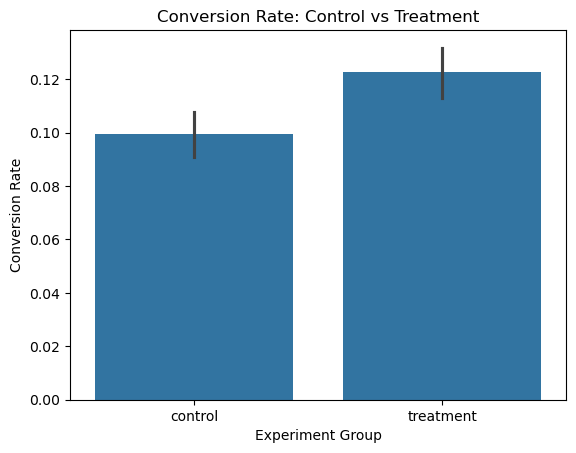

In [26]:
sns.barplot(x="experiment_group", y="purchase", data=df)
plt.title("Conversion Rate: Control vs Treatment")
plt.ylabel("Conversion Rate")
plt.xlabel("Experiment Group")

## Revenue Comparision

Text(0, 0.5, 'Revenue')

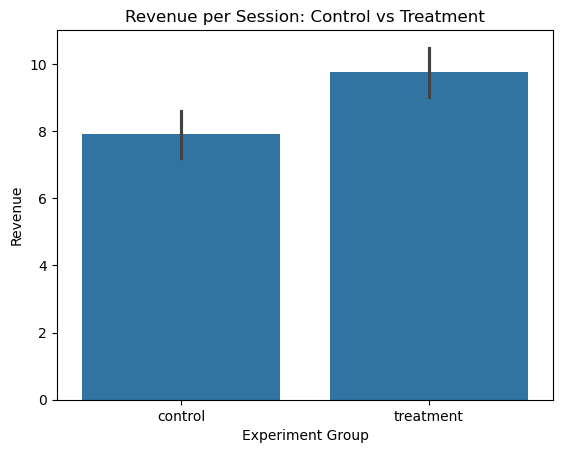

In [33]:
sns.barplot(x="experiment_group", y="order_value", data=df)

plt.title("Revenue per Session: Control vs Treatment")
plt.xlabel("Experiment Group")
plt.ylabel("Revenue")


## Purchase Distribution

Text(0, 0.5, 'Frequency')

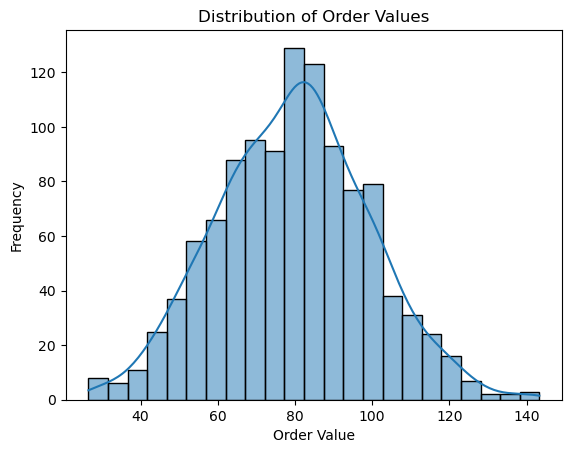

In [36]:
sns.histplot(df[df["purchase"] == 1]["order_value"],kde=True)

plt.title("Distribution of Order Values")
plt.xlabel("Order Value")
plt.ylabel("Frequency")
# This shows how order values are distributed.
# Are most purchases small?
# Are there big purchases?
# Is the distribution skewed?


# project report
The treatment group using the new checkout page achieved a 12.25% conversion rate, 
compared to 9.93% in the control group,representing a 2.32 percentage point increase.

Additionally, the treatment group generated higher revenue per user (9.76 vs 7.90).

A two-sample t-test produced a p-value of 0.00022, indicating the improvement is statistically significant.

Recommendation: The company should roll out the new checkout page to all users as 
it improves both conversion rate and revenue.